In [13]:
import pandas as pd

pd.set_option("display.max_rows",30)

human_Percentages_df=pd.read_csv("../human_predictions/output_all.csv")
llm_Percentages_df=pd.read_csv("../llm_predictions/result_vwp50_scene_table.csv")

llm_Percentages_df=llm_Percentages_df.rename(columns={"Item":"stimuliId","Condition":"condition","Object":"obj"})
llm_Percentages_df["stimuliId"] = llm_Percentages_df["stimuliId"].astype(int)

#OBSOLET AFTER UPDATE
#remove strange star symbols that come up in strings (even though we like stars they dont help here, sry Fei //Jonathan ^^)
#llm_Percentages_df["obj"] = (
#    llm_Percentages_df["obj"]
#    .str.replace(r"^[^\w]+", "", regex=True)
#    .str.strip()
#)

#fixing different denotations of condition:
llm_Percentages_df["condition"] = llm_Percentages_df["condition"].replace("Restrictive", "restrictive")
llm_Percentages_df["condition"] = llm_Percentages_df["condition"].replace("Non-restr.", "non-restrictive")
#r=llm_Percentages_df[llm_Percentages_df["obj"]=="cake"]
#r
llm_Percentages_df

,stimuliId,condition,Verb,obj,Is_Target,Surprisal (bits),P_norm,Rank,ΔS (bits)
0,1,restrictive,eat,cake,True,5.961,0.9734,1,6.482
1,1,restrictive,eat,ball,False,11.156,0.0266,2,-6.202
2,1,restrictive,eat,toy car,False,20.215,0.0000,3,-5.087
3,1,restrictive,eat,toy train,False,22.952,0.0000,4,-6.074
4,1,non-restrictive,move,ball,False,4.953,0.9934,1,-6.202
...,...,...,...,...,...,...,...,...,...
395,50,restrictive,lick,rubber band,False,17.832,0.0203,4,1.492
396,50,non-restrictive,pick up,scissors,False,11.491,0.5686,1,-5.245
397,50,non-restrictive,pick up,envelope,False,12.000,0.3994,2,-0.571
398,50,non-restrictive,pick up,stamp,True,15.759,0.0295,3,0.876


In [33]:
#TODO: investigate human percentages for trials where all are zero
human_Percentages_df[human_Percentages_df["stimuliId"]==45]

,stimuliId,partID,condition,obj,percent
160,45,1,non-restrictive,dough,0.000000
161,45,1,non-restrictive,glass,0.000000
162,45,1,non-restrictive,ladle,0.000000
163,45,1,non-restrictive,hammer,0.000000
228,45,2,restrictive,hammer,0.000000
229,45,2,restrictive,dough,0.000000
230,45,2,restrictive,glass,0.000000
231,45,2,restrictive,ladle,0.000000
564,45,3,non-restrictive,hammer,0.000000
565,45,3,non-restrictive,dough,0.000000


In [40]:
#first before comparing we need to aggregate. not over all participants of a trial 
# but over all participants with the same contidion (4-restrictive 4 non restrictive) however some may not be present yet...
avg_df_human = (
    human_Percentages_df
    .groupby(["stimuliId", "condition", "obj"])
    .agg(
        avg_percent=("percent", "mean"),
        n_participants=("partID", "nunique")
    )
    .reset_index()
)

avg_df_human.to_csv("01_intermediate_human_aggregation.csv")

#another approach would be to exclude all those that have only zero percentages before aggregating. here we do it after to retain as many values as possible
avg_df_human["total_percent"] = (
    avg_df_human.groupby(["stimuliId", "condition"])["avg_percent"]
      .transform("sum")
)
avg_df_human_totalOne=avg_df_human[avg_df_human["total_percent"]==1.0] #only 44 !!!!! ???
avg_df_human_totalOne

,stimuliId,condition,obj,avg_percent,n_participants,total_percent
12,2,restrictive,chair,0.000000,3,1.0
13,2,restrictive,cheese,0.000000,3,1.0
14,2,restrictive,lipstick,0.000000,3,1.0
15,2,restrictive,wine,1.000000,3,1.0
36,5,restrictive,acorns,0.507246,2,1.0
...,...,...,...,...,...,...
387,49,non-restrictive,pouch,0.000000,2,1.0
388,49,non-restrictive,pump,0.000000,2,1.0
389,49,non-restrictive,rubberband,0.000000,1,1.0
390,49,non-restrictive,scissors,0.000000,1,1.0


In [ ]:
#check after avergaing over all participants how many stimuli got only 0 percentages...

In [41]:
#now we want to create a shared dataframe that maps the percentages contains both human and llm prediction per word per condition

#merge on ritgh because llm should be calculated for all

#maybe there still remains some kind of mismatch ? 400 rows (4*50*2 seems how it should be, why are there more )
#inner 378 --> this is most likely because we dont have values for all combinations yet //participant 6,7,8 are missing. 

#so for know we use inner

shared_df=avg_df_human.merge(llm_Percentages_df, on=["stimuliId","condition","obj"],how="inner")

shared_totalOne_df=avg_df_human_totalOne.merge(llm_Percentages_df, on=["stimuliId","condition","obj"],how="inner")
shared_totalOne_df

,stimuliId,condition,obj,avg_percent,n_participants,total_percent,Verb,Is_Target,Surprisal (bits),P_norm,Rank,ΔS (bits)
0,2,restrictive,chair,0.000000,3,1.0,drink,False,15.609,0.0004,4,-4.301
1,2,restrictive,cheese,0.000000,3,1.0,drink,False,12.288,0.0042,2,0.177
2,2,restrictive,lipstick,0.000000,3,1.0,drink,False,14.742,0.0008,3,-0.467
3,2,restrictive,wine,1.000000,3,1.0,drink,True,4.401,0.9946,1,6.303
4,5,restrictive,acorns,0.507246,2,1.0,bounce,False,14.782,0.0001,2,0.878
...,...,...,...,...,...,...,...,...,...,...,...,...
33,42,restrictive,stone,0.333333,3,1.0,squeeze,False,10.650,0.3901,2,-2.051
34,49,non-restrictive,balloon,1.000000,2,1.0,carry,True,12.900,0.0398,3,5.998
35,49,non-restrictive,flag,0.000000,2,1.0,carry,False,8.400,0.9010,1,-2.689
36,49,non-restrictive,pouch,0.000000,2,1.0,carry,False,12.420,0.0555,2,-0.128


Text(0.5, 1.0, 'LLM predictions vs. Human predictions')

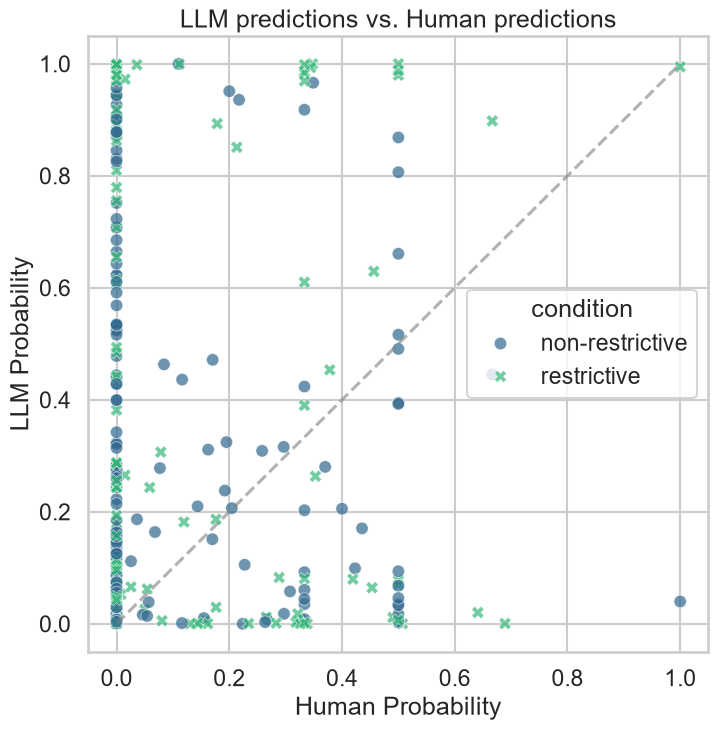

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(8, 8))

sns.scatterplot(
    data=shared_df,
    x="avg_percent",
    y="P_norm",
    hue="condition",       
    style="condition",     
    s=80,                 
    alpha=0.7,             
    edgecolor="white",
    linewidth=0.5,
    palette="viridis",
    ax=ax
)

# Diagonale (perfekte Übereinstimmung) einzeichnen
lims = [0, 1]  # anpassen, falls Werte nicht zwischen 0 und 1 liegen
ax.plot(lims, lims, ls="--", color="gray", alpha=0.6, label="perfect agreement")

ax.set_xlabel("Human Probability")
ax.set_ylabel("LLM Probability")
ax.set_title("LLM predictions vs. Human predictions")

Text(0.5, 1.0, 'LLM predictions vs. Human predictions')

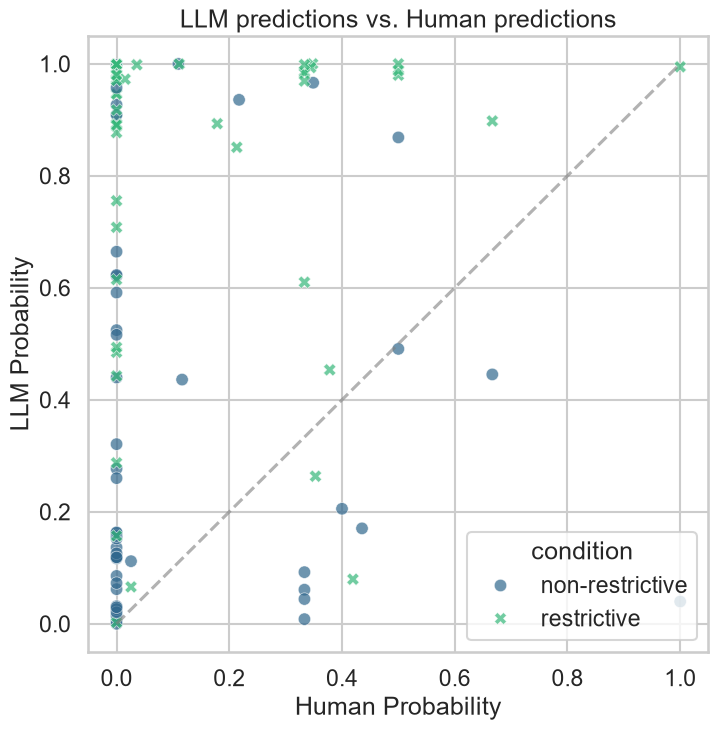

In [43]:
shared_df_targets=shared_df[shared_df["Is_Target"]==True]


fig, ax = plt.subplots(figsize=(8, 8))

sns.scatterplot(
    data=shared_df_targets,
    x="avg_percent",
    y="P_norm",
    hue="condition",       
    style="condition",     
    s=80,                 
    alpha=0.7,             
    edgecolor="white",
    linewidth=0.5,
    palette="viridis",
    ax=ax
)

# Diagonale (perfekte Übereinstimmung) einzeichnen
lims = [0, 1]  # anpassen, falls Werte nicht zwischen 0 und 1 liegen
ax.plot(lims, lims, ls="--", color="gray", alpha=0.6, label="perfect agreement")

ax.set_xlabel("Human Probability")
ax.set_ylabel("LLM Probability")
ax.set_title("LLM predictions vs. Human predictions")

Text(0.5, 1.0, 'LLM predictions vs. Human predictions')

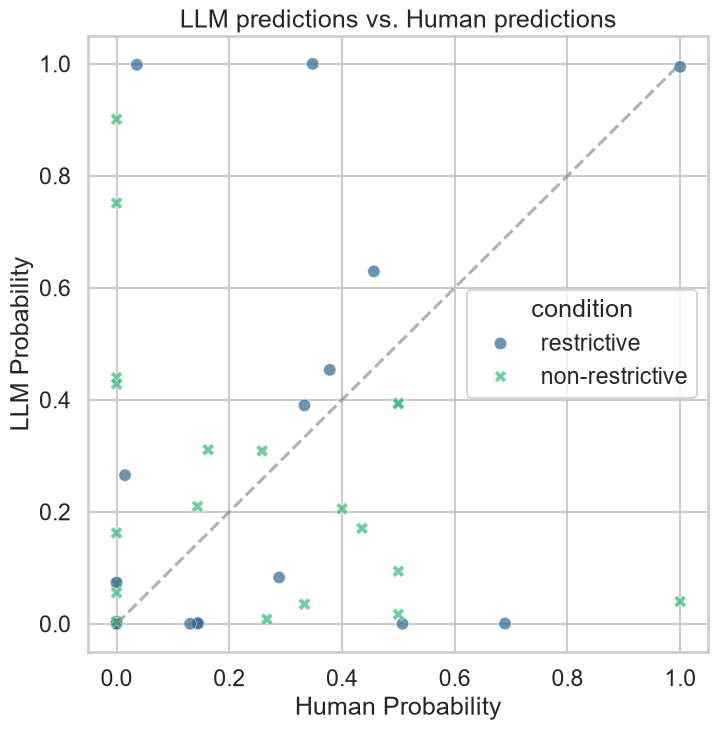

In [42]:
fig, ax = plt.subplots(figsize=(8, 8))

sns.scatterplot(
    data=shared_totalOne_df,
    x="avg_percent",
    y="P_norm",
    hue="condition",       
    style="condition",     
    s=80,                 
    alpha=0.7,             
    edgecolor="white",
    linewidth=0.5,
    palette="viridis",
    ax=ax
)

# Diagonale (perfekte Übereinstimmung) einzeichnen
lims = [0, 1]  # anpassen, falls Werte nicht zwischen 0 und 1 liegen
ax.plot(lims, lims, ls="--", color="gray", alpha=0.6, label="perfect agreement")

ax.set_xlabel("Human Probability")
ax.set_ylabel("LLM Probability")
ax.set_title("LLM predictions vs. Human predictions")

In [44]:
from scipy.spatial.distance import jensenshannon

jsd_df = (
    shared_totalOne_df
    .groupby(["stimuliId", "condition"])
    .apply(
        lambda g: jensenshannon(
            g.sort_values("obj")["avg_percent"],
            g.sort_values("obj")["P_norm"]
        ) ** 2
    )
    .reset_index(name="JSD")
)
jsd_df

,stimuliId,condition,JSD
0,2,restrictive,0.001875
1,5,restrictive,0.307866
2,11,restrictive,0.072091
3,17,non-restrictive,0.423025
4,28,non-restrictive,0.256682
5,35,restrictive,0.609261
6,36,non-restrictive,0.046065
7,38,non-restrictive,0.349608
8,42,restrictive,0.058558
9,49,non-restrictive,0.608701


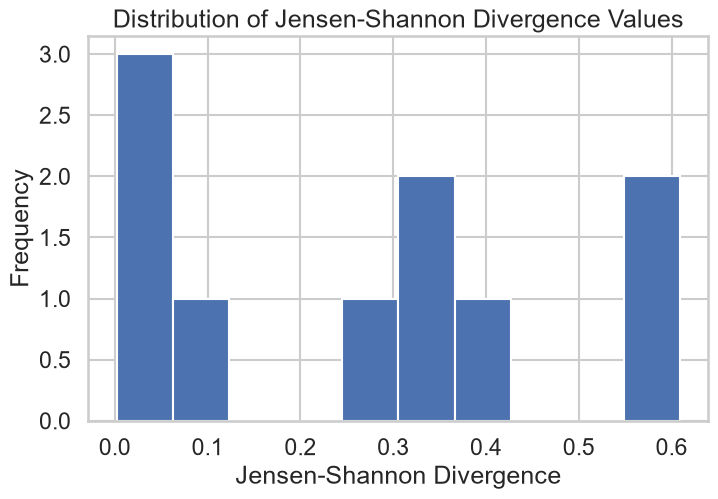

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(jsd_df["JSD"], bins=10)

plt.xlabel("Jensen-Shannon Divergence")
plt.ylabel("Frequency")
plt.title("Distribution of Jensen-Shannon Divergence Values")

plt.show()

In [60]:
sd_all_df = (
    shared_df
    .groupby(["stimuliId", "condition"])
    .apply(
        lambda g: jensenshannon(
            g.sort_values("obj")["avg_percent"],
            g.sort_values("obj")["P_norm"]
        ) ** 2
    )
    .reset_index(name="JSD")
)
#sd_all_df=sd_all_df[sd_all_df["condition"]=="non-restrictive"]

c:\Users\jonat\anaconda3\envs\etstudy\Lib\site-packages\scipy\spatial\distance.py:1280: RuntimeWarning: invalid value encountered in divide
  p = p / np.sum(p, axis=axis, keepdims=True)


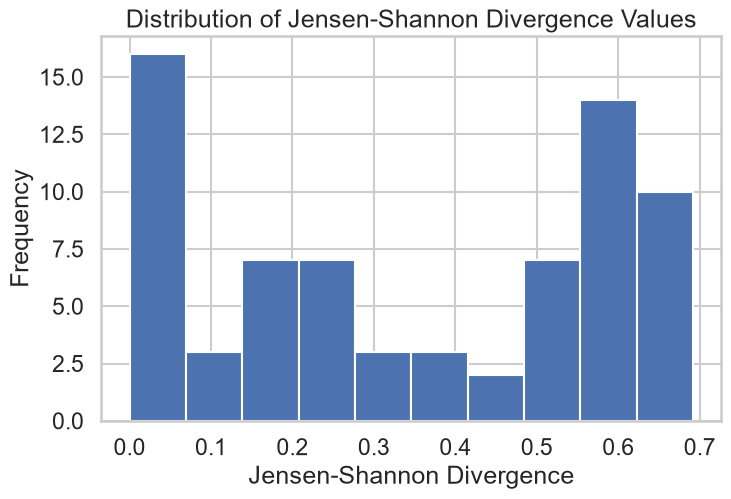

In [61]:
plt.figure(figsize=(8, 5))

plt.hist(sd_all_df["JSD"], bins=10)

plt.xlabel("Jensen-Shannon Divergence")
plt.ylabel("Frequency")
plt.title("Distribution of Jensen-Shannon Divergence Values")

plt.show()